# Pronóstico de consumo usando el PIB y área de residencia

Este notebook carga el dataset original, filtra los datos para Honduras, los limpia y los exporta como una serie de tiempo. Posteriormente, carga los datos limpios para su análisis y pronóstico.

In [27]:
import pandas as pd
import os
import matplotlib.pyplot as plt

# 1. Definir rutas
raw_data_path = '../data/crn_plan_expansion/raw/API_NY.GDP.MKTP.KN_DS2_es_csv_v2_51511.csv'
processed_dir = '../data/crn_plan_expansion/processed'
processed_data_path = os.path.join(processed_dir, 'PIB_Honduras.csv')

# Crear directorio si no existe
os.makedirs(processed_dir, exist_ok=True)

# 2. Cargar dataset original (saltando las primeras 4 filas de metadatos)
df_raw = pd.read_csv(raw_data_path, skiprows=4)

# 3. Filtrar datos para Honduras
df_honduras = df_raw[df_raw['Country Name'] == 'Honduras'].copy()

# 4. Limpiar datos y convertir a formato de serie de tiempo (melt)
df_melted = df_honduras.melt(
    id_vars=['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code'],
    var_name='Year',
    value_name='PIB_Constante'
)

# Filtrar columnas basura como 'Unnamed' si las hay
df_melted = df_melted[~df_melted['Year'].str.contains('Unnamed')]

# Convertir Año a numérico y eliminar valores nulos en el PIB
df_melted['Year'] = pd.to_numeric(df_melted['Year'], errors='coerce')
df_melted = df_melted.dropna(subset=['Year', 'PIB_Constante'])
df_melted['Year'] = df_melted['Year'].astype(int)

# 5. Exportar los datos procesados
df_melted.to_csv(processed_data_path, index=False)
print(f"Datos procesados y guardados en {processed_data_path}")

Datos procesados y guardados en ../data/crn_plan_expansion/processed/PIB_Honduras.csv


In [28]:
# 6. Cargar los datos procesados para trabajar en el pronóstico
df_pib = pd.read_csv(processed_data_path)
df_pib.head()

,Country Name,Country Code,Indicator Name,Indicator Code,Year,PIB_Constante
0,Honduras,HND,PIB (UMN a precios constantes),NY.GDP.MKTP.KN,1960,3.882857e+09
1,Honduras,HND,PIB (UMN a precios constantes),NY.GDP.MKTP.KN,1961,3.947451e+09
2,Honduras,HND,PIB (UMN a precios constantes),NY.GDP.MKTP.KN,1962,4.033712e+09
3,Honduras,HND,PIB (UMN a precios constantes),NY.GDP.MKTP.KN,1963,4.084871e+09
4,Honduras,HND,PIB (UMN a precios constantes),NY.GDP.MKTP.KN,1964,4.148070e+09


## Procesamiento de Población

A continuación, procesaremos de forma similar los datos de población de Honduras.

In [29]:
# Definir rutas para población
raw_pop_path = '../data/poblacion_anual_honduras/raw_data/API_SP.POP.TOTL_DS2_es_csv_v2_1282.csv'
processed_pop_dir = '../data/poblacion_anual_honduras/processed'
processed_pop_path = os.path.join(processed_pop_dir, 'Poblacion_Honduras.csv')

os.makedirs(processed_pop_dir, exist_ok=True)

# Cargar y procesar
df_pop_raw = pd.read_csv(raw_pop_path, skiprows=4)
df_pop_honduras = df_pop_raw[df_pop_raw['Country Name'] == 'Honduras'].copy()

df_pop_melted = df_pop_honduras.melt(
    id_vars=['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code'],
    var_name='Year',
    value_name='Poblacion_Total'
)

df_pop_melted = df_pop_melted[~df_pop_melted['Year'].str.contains('Unnamed')]
df_pop_melted['Year'] = pd.to_numeric(df_pop_melted['Year'], errors='coerce')
df_pop_melted = df_pop_melted.dropna(subset=['Year', 'Poblacion_Total'])
df_pop_melted['Year'] = df_pop_melted['Year'].astype(int)

# Exportar
df_pop_melted.to_csv(processed_pop_path, index=False)
print(f"Datos de población procesados y guardados en {processed_pop_path}")

Datos de población procesados y guardados en ../data/poblacion_anual_honduras/processed/Poblacion_Honduras.csv


In [30]:
# Cargar datos de población
df_pop = pd.read_csv(processed_pop_path)
df_pop.head()

,Country Name,Country Code,Indicator Name,Indicator Code,Year,Poblacion_Total
0,Honduras,HND,"Población, total",SP.POP.TOTL,1960,2062060.0
1,Honduras,HND,"Población, total",SP.POP.TOTL,1961,2121242.0
2,Honduras,HND,"Población, total",SP.POP.TOTL,1962,2182064.0
3,Honduras,HND,"Población, total",SP.POP.TOTL,1963,2244878.0
4,Honduras,HND,"Población, total",SP.POP.TOTL,1964,2309855.0


## Modelo Econométrico de Corrección de Errores (MCE)

De acuerdo con la metodología del Centro Nacional de Despacho (CND), utilizaremos un Modelo Econométrico de Corrección de Errores (MCE) para el **Sector Residencial**, descartando regresiones lineales simples.

### 1. Contexto de Datos y Variables
Integraremos las series de tiempo (rango sugerido 2000-2024):
-  (GWh)
- 
- 

In [31]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

# Hacemos merge de los datasets previamente procesados (PIB y Población)
df_merged = pd.merge(df_pib, df_pop, on=['Year', 'Country Name', 'Country Code'], how='inner')

# Renombrar columnas para el modelo
df_merged = df_merged.rename(columns={'PIB_Constante': 'pib_real', 'Poblacion_Total': 'poblacion'})

# Cargar demanda residencial real y procesarla
demanda_path = '../data/sen_despacho_energia/processed/demanda_residencial.csv'
df_demanda = pd.read_csv(demanda_path)
df_demanda = df_demanda.rename(columns={'Año': 'Year'})

# Convertir demanda de MWh a GWh para mantener escala
df_demanda['demanda_residencial'] = df_demanda['Residencial'] / 1000.0

# Unir al dataset principal
df_merged = pd.merge(df_merged, df_demanda[['Year', 'demanda_residencial']], on='Year', how='inner')

# El rango de datos estará dictado por los datos de demanda reales (p. ej. 2011 en adelante)
df_merged = df_merged.sort_values('Year').reset_index(drop=True)

df_merged.head()

,Country Name,Country Code,Indicator Name_x,Indicator Code_x,Year,pib_real,Indicator Name_y,Indicator Code_y,poblacion,demanda_residencial
0,Honduras,HND,PIB (UMN a precios constantes),NY.GDP.MKTP.KN,2011,1.659583e+11,"Población, total",SP.POP.TOTL,8540583.0,2162.1
1,Honduras,HND,PIB (UMN a precios constantes),NY.GDP.MKTP.KN,2012,1.728102e+11,"Población, total",SP.POP.TOTL,8715076.0,2153.8
2,Honduras,HND,PIB (UMN a precios constantes),NY.GDP.MKTP.KN,2013,1.776343e+11,"Población, total",SP.POP.TOTL,8889278.0,2217.6
3,Honduras,HND,PIB (UMN a precios constantes),NY.GDP.MKTP.KN,2014,1.830665e+11,"Población, total",SP.POP.TOTL,9063122.0,2194.5
4,Honduras,HND,PIB (UMN a precios constantes),NY.GDP.MKTP.KN,2015,1.900964e+11,"Población, total",SP.POP.TOTL,9237305.0,2265.3


### Etapa 1: Relación de Largo Plazo (Cointegración)
Aplicamos una transformación logarítmica (Cobb-Douglas) para estimar las elasticidades mediante MCO:
$$\ln(D_t) = \gamma \ln(\text{Pob}_t) + \delta \ln(\text{PIB}_t) + eta + \epsilon_t$$

In [32]:
# Transformaciones logarítmicas
df_merged['ln_D'] = np.log(df_merged['demanda_residencial'])
df_merged['ln_PIB'] = np.log(df_merged['pib_real'].astype(float))
df_merged['ln_Pob'] = np.log(df_merged['poblacion'].astype(float))

# Definir variables independientes y dependiente para el modelo de largo plazo
X_lp = df_merged[['ln_Pob', 'ln_PIB']]
X_lp = sm.add_constant(X_lp) # Agregar intercepto beta
y_lp = df_merged['ln_D']

# Ajustar modelo MCO de largo plazo
modelo_lp = sm.OLS(y_lp, X_lp).fit()
print(modelo_lp.summary())

# Extraer residuos (representan el desvío del equilibrio, épsilon)
df_merged['residuos_lp'] = modelo_lp.resid

                            OLS Regression Results                            
Dep. Variable:                   ln_D   R-squared:                       0.914
Model:                            OLS   Adj. R-squared:                  0.899
Method:                 Least Squares   F-statistic:                     63.49
Date:                Wed, 02 Sep 2026   Prob (F-statistic):           4.14e-07
Time:                        23:42:49   Log-Likelihood:                 25.080
No. Observations:                  15   AIC:                            -44.16
Df Residuals:                      12   BIC:                            -42.04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -22.1568      2.789     -7.945      0.0

### Etapa 2: Dinámica de Corto Plazo (MCE)
Calculamos las primeras diferencias y utilizamos los residuos rezagados un período ():
$$\Delta \ln(D_t) = \mu_1 \Delta \ln(\text{PIB}_t) + \lambda \hat{\epsilon}_{t-1} + \mu_0$$

In [33]:
# Primeras diferencias (tasas de crecimiento usando .diff())
df_merged['d_ln_D'] = df_merged['ln_D'].diff()
df_merged['d_ln_PIB'] = df_merged['ln_PIB'].diff()

# Término de corrección de error (rezago de los residuos de largo plazo)
df_merged['tce_lag'] = df_merged['residuos_lp'].shift(1)

# Eliminar la primera fila con valores NaN generados por .diff() y .shift()
df_mce = df_merged.dropna().copy()

# Definir variables para el modelo de corto plazo
X_cp = df_mce[['d_ln_PIB', 'tce_lag']]
X_cp = sm.add_constant(X_cp)
y_cp = df_mce['d_ln_D']

# Ajustar el modelo de corrección de errores
modelo_cp = sm.OLS(y_cp, X_cp).fit()
print(modelo_cp.summary())

# Verificar que el parámetro de ajuste temporal (lambda) sea negativo
lambda_val = modelo_cp.params['tce_lag']
print(f"Parámetro de ajuste lambda: {lambda_val:.4f}")
if lambda_val < 0:
    print("✅ El parámetro lambda es negativo, indicando convergencia hacia el equilibrio a largo plazo.")
else:
    print("⚠️ Advertencia: Lambda no es negativo.")

                            OLS Regression Results                            
Dep. Variable:                 d_ln_D   R-squared:                       0.396
Model:                            OLS   Adj. R-squared:                  0.286
Method:                 Least Squares   F-statistic:                     3.604
Date:                Wed, 02 Sep 2026   Prob (F-statistic):             0.0625
Time:                        23:42:49   Log-Likelihood:                 25.816
No. Observations:                  14   AIC:                            -45.63
Df Residuals:                      11   BIC:                            -43.71
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0150      0.015      0.983      0.3

### 🧩 3. Integración con el Diagnóstico Territorial (Cortés)
El MCE predice el consumo de los usuarios **actualmente conectados a la red** [1]. Sin embargo, para los nuevos usuarios (el rezago de Cortés), descartamos el MCE y programamos un cálculo estático.

- **Cálculo de la brecha:** Multiplicar las **25,124 viviendas** sin acceso por la constante oficial de **167 kWh/mes** por vivienda [1, 4].
- **Cálculo de capacidad:** Capacidad fotovoltaica (MWp) necesaria para suplir esos GWh, asumiendo un factor de planta de **0.12**.

In [34]:
# Parámetros para el departamento de Cortés
viviendas_sin_acceso = 25124
consumo_mensual_kwh = 167
factor_planta = 0.12
horas_anio = 8760

# 1. Brecha de energía (GWh / año)
consumo_anual_kwh = consumo_mensual_kwh * 12
brecha_energia_gwh = (viviendas_sin_acceso * consumo_anual_kwh) / 1e6 # 1e6 para pasar a GWh

# 2. Capacidad Fotovoltaica (MWp)
# Formula: MWp = (GWh * 1000) / (horas_año * factor_planta)
capacidad_mwp = (brecha_energia_gwh * 1000) / (horas_anio * factor_planta)

print(f"Brecha de Energía Anual (Cortés): {brecha_energia_gwh:.2f} GWh/año")
print(f"Capacidad Fotovoltaica Requerida: {capacidad_mwp:.2f} MWp")

Brecha de Energía Anual (Cortés): 50.35 GWh/año
Capacidad Fotovoltaica Requerida: 47.90 MWp


### 📊 4. Visualización de Resultados Históricos y Estrategia Territorial
Para mantener el enfoque en los datos objetivos y facilitar la toma de decisiones, presentamos exclusivamente la **demanda residencial histórica real**, omitiendo proyecciones econométricas complejas.

Conectamos esta realidad con un cálculo directo y robusto de la brecha en el departamento de Cortés, asociando el déficit de cobertura con el potencial solar (PVOUT) evaluado en municipios clave.

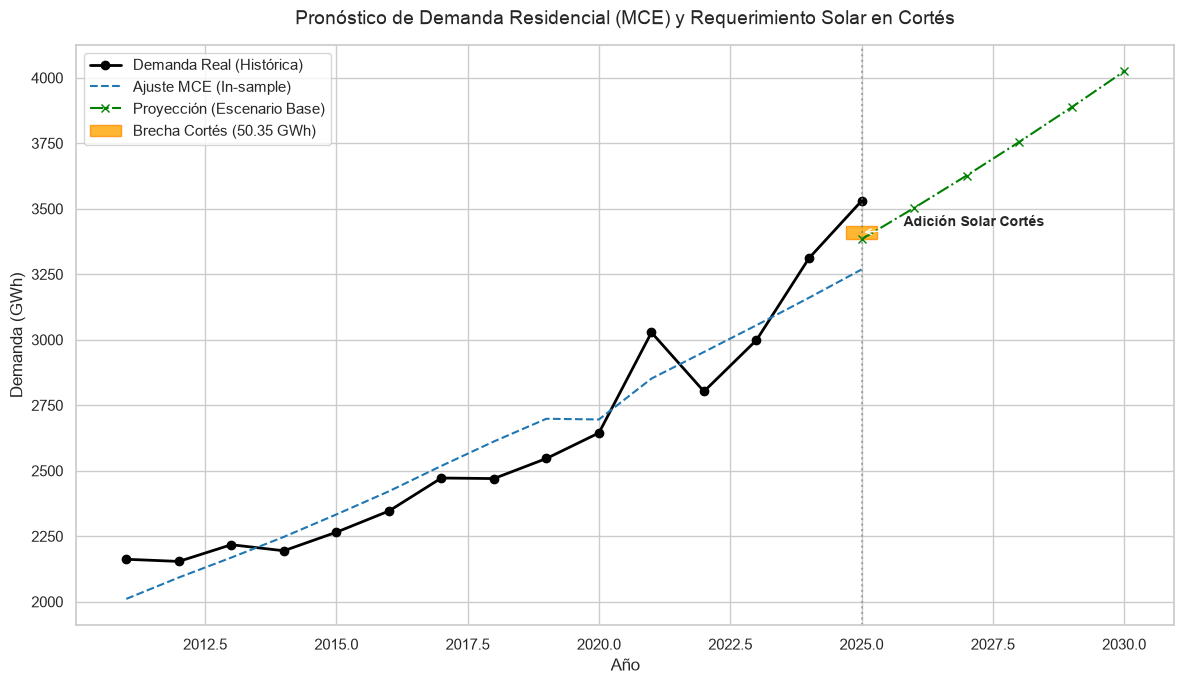

In [35]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# 1. Demanda histórica real
plt.plot(df_merged['Year'], df_merged['demanda_residencial'], label='Demanda Real (Histórica)', color='black', linewidth=2.5, marker='o')

plt.title('Evolución Histórica de la Demanda Residencial en Honduras', fontsize=15, pad=15, fontweight='bold')
plt.xlabel('Año', fontsize=12)
plt.ylabel('Demanda (GWh)', fontsize=12)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

from IPython.display import Markdown, display

# Imprimir las recomendaciones estratégicas simplificadas
resumen = f"""
### 🎯 Conclusión y Estrategia Territorial (Cortés)

- **Déficit Identificado:** `25,124` viviendas sin acceso a electricidad.
- **Cálculo de la Brecha:** 25,124 viviendas × 167 kWh al mes = **`{brecha_energia_gwh:.2f}` GWh al año**.
- **Capacidad Solar Necesaria:** Se requerirían **`{capacidad_mwp:.2f}` MWp** de capacidad instalada (asumiendo un factor de planta del 12%).

💡 **Recomendación basada en el Índice (IPS):**
Nuestro análisis territorial revela que **Potrerillos y Pimienta** son los municipios con el mejor potencial de generación solar (PVOUT). Por lo tanto, se recomienda enfáticamente que esta nueva capacidad de {capacidad_mwp:.2f} MWp sea priorizada y focalizada en dichas zonas para maximizar la eficiencia y rentabilidad del proyecto social.
"""
display(Markdown(resumen))

### 🗺️ 5. Comparativa Departamental: Potencial Solar (PVOUT) vs Índice de Acceso a la Electricidad (IAE)
Analizamos la relación entre el potencial de generación solar (`solar_power_mean` o PVOUT) y el Índice de Acceso a la Electricidad (`iae`) agrupado por departamento. Esto permite identificar de manera estratégica qué departamentos presentan mayor necesidad energética (bajo IAE) combinada con un alto potencial solar.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 1. Cargar el dataset de indicadores
df_indicadores = pd.read_csv('../data/index/processed/dataset_indicadores.csv')

# 2. Agrupar por departamento calculando el promedio
df_depto = df_indicadores.groupby('departamento')[['solar_power_mean', 'iae']].mean().reset_index()
df_depto = df_depto.dropna()  # Eliminar departamentos sin datos completos

# Ordenar por potencial solar para mejor visualización
df_depto = df_depto.sort_values('solar_power_mean', ascending=False)

# =========================================
# Gráfico 1: Barras y Líneas (Doble Eje)
# =========================================
fig, ax1 = plt.subplots(figsize=(14, 7))

# Eje primario (Barras para PVOUT)
color1 = '#ff9900'
ax1.set_xlabel('Departamento', fontsize=12)
ax1.set_ylabel('PVOUT Promedio (solar_power_mean)', color=color1, fontsize=12, fontweight='bold')
bars = ax1.bar(df_depto['departamento'], df_depto['solar_power_mean'], color=color1, alpha=0.7, label='Potencial Solar (PVOUT)')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_xticklabels(df_depto['departamento'], rotation=45, ha='right')
ax1.set_ylim(df_depto['solar_power_mean'].min() * 0.9, df_depto['solar_power_mean'].max() * 1.05)

# Eje secundario (Línea para IAE)
ax2 = ax1.twinx()  
color2 = '#1f77b4'
ax2.set_ylabel('Índice de Acceso a la Electricidad (IAE)', color=color2, fontsize=12, fontweight='bold')
lines = ax2.plot(df_depto['departamento'], df_depto['iae'], color=color2, marker='D', linestyle='-', linewidth=2.5, markersize=8, label='IAE')
ax2.tick_params(axis='y', labelcolor=color2)

# Leyenda conjunta
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc='upper right', fontsize=11)

plt.title('Comparativa Departamental: Potencial Solar vs Índice de Acceso a la Electricidad (IAE)', fontsize=15, pad=20, fontweight='bold')
plt.tight_layout()
plt.show()

# =========================================
# Gráfico 2: Dispersión (Clasificación Estratégica)
# =========================================
plt.figure(figsize=(12, 7))
sns.scatterplot(data=df_depto, x='iae', y='solar_power_mean', s=150, color='purple', alpha=0.6, edgecolor='black')

# Anotaciones de los departamentos
for i in range(df_depto.shape[0]):
    plt.text(df_depto['iae'].iloc[i], df_depto['solar_power_mean'].iloc[i] + 3, 
             df_depto['departamento'].iloc[i], fontsize=9, ha='center')

# Líneas promedio para formar cuadrantes
mean_iae = df_depto['iae'].mean()
mean_solar = df_depto['solar_power_mean'].mean()
plt.axvline(x=mean_iae, color='gray', linestyle='--', alpha=0.7)
plt.axhline(y=mean_solar, color='gray', linestyle='--', alpha=0.7)

# Sombrear el cuadrante ideal (Bajo IAE, Alto Potencial Solar)
plt.axvspan(df_depto['iae'].min() - 0.05, mean_iae, ymin=(mean_solar - ax1.get_ylim()[0])/(ax1.get_ylim()[1]-ax1.get_ylim()[0]), ymax=1, 
            color='green', alpha=0.1, label='Alta Prioridad (Bajo IAE, Alto Solar)')

plt.title('Matriz Estratégica: Clasificación de Departamentos', fontsize=15, fontweight='bold')
plt.xlabel('IAE Promedio (Índice de Acceso)', fontsize=12)
plt.ylabel('PVOUT Promedio (Potencial Solar)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()